# Clase 3 · Análisis exploratorio de datos II

**Módulo 1: Introducción y fundamentos estadísticos** · Diplomado en Ciencia de Datos Aplicada · UTFSM

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/daniopitz/diplomado-cdd/blob/main/03_eda_bivariado_colab.ipynb)

Versión para **Google Colab**. Antes de trabajar, guarde su propia copia con `Archivo > Guardar una copia en Drive`.

Objetivos de la sesión: analizar relaciones entre pares de variables (correlación, grupos y tablas de contingencia), ajustar una primera regresión y graficar con buenas prácticas.

**El norte de todo esto son los modelos**: la correlación dice qué variables prometen como predictoras, la matriz ayuda a elegirlas, y la regresión de hoy ya es un modelo, el primero del diplomado.

## 1. Preparación

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

# Gráficos más nítidos en pantallas de alta resolución
%config InlineBackend.figure_format = "retina"


In [2]:
BASE = (
    "https://raw.githubusercontent.com/daniopitz/diplomado-cdd/"
    "main/datos/eod_stgo/"
)
# Alternativa sin URL: suba eod_stgo.zip, descomprima y use la ruta local:
# !unzip -q eod_stgo.zip -d .
# BASE = "eod_stgo/"

In [3]:
viajes = pd.read_csv(BASE + "viajes.csv", sep=";", decimal=",", low_memory=False)
viajes.shape

(113591, 35)

In [4]:
hogares = pd.read_csv(BASE + "Hogares.csv", sep=";", decimal=",", low_memory=False)
hogares.shape

(18264, 21)

Hoy usamos también la tabla de **personas**: una fila por persona encuestada, con su sexo, edad y ocupación.

In [5]:
personas = pd.read_csv(BASE + "personas.csv", sep=";", decimal=",", low_memory=False)
personas.shape

(60054, 39)

In [6]:
from sklearn.datasets import load_iris

iris = load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
nombres = {0: "setosa", 1: "versicolor", 2: "virginica"}
iris_df["species"] = pd.Series(iris.target).map(nombres)
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 2. Los conceptos, con iris

### El gráfico de dispersión

La clase pasada describimos variables de a una; hoy las cruzamos de a dos. Para dos cuantitativas, el gráfico es la **dispersión** (scatter): cada punto es una fila, y sus coordenadas son los valores de las dos variables.

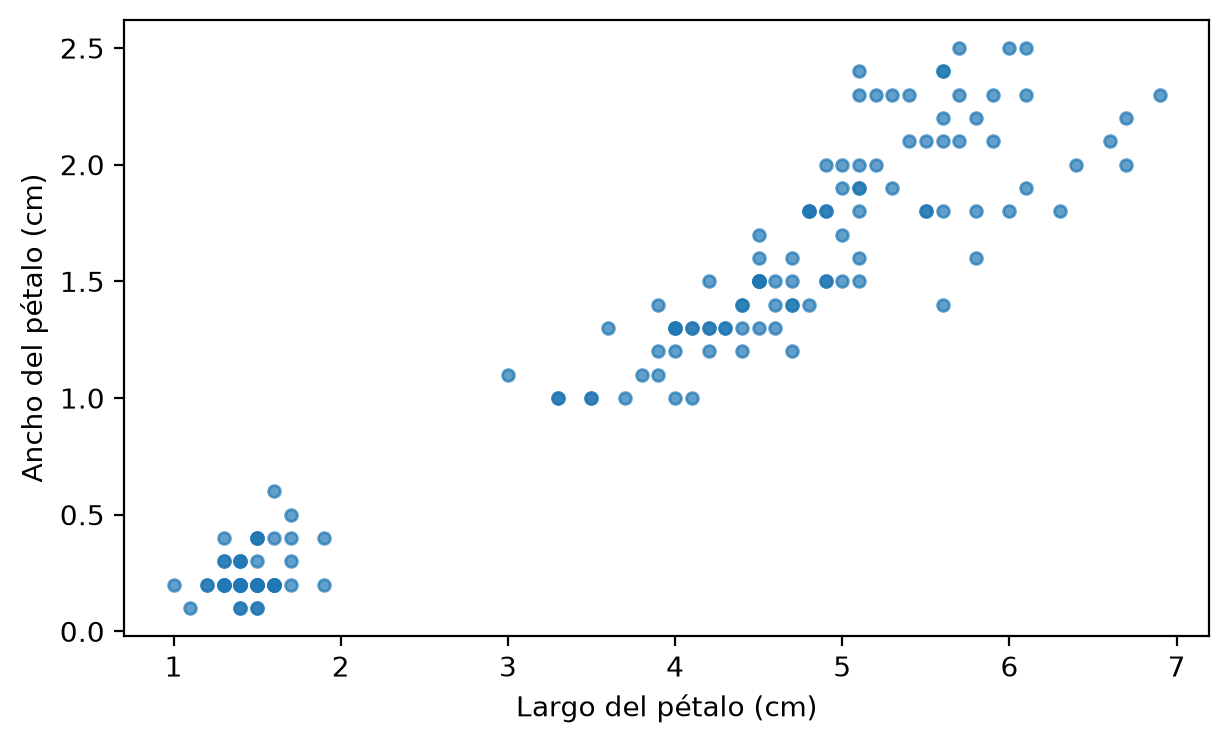

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(iris_df["petal length (cm)"], iris_df["petal width (cm)"],
           s=18, alpha=0.7)
ax.set_xlabel("Largo del pétalo (cm)")
ax.set_ylabel("Ancho del pétalo (cm)")
plt.show()

La nube sube en diagonal: pétalos más largos vienen con pétalos más anchos.

### La correlación

La **correlación de Pearson** resume esa relación en un número entre −1 y 1: fuerza y signo de la relación lineal. En Pandas es un método de la columna:

In [8]:
iris_df["petal length (cm)"].corr(iris_df["petal width (cm)"])

np.float64(0.9628654314027961)

0,96: una relación lineal casi perfecta.

### La matriz de correlación

Con más de dos variables, los pares se multiplican; la matriz los muestra todos de una vez. La diagonal es 1 (toda variable correlaciona perfecto consigo misma) y la matriz es simétrica:

In [9]:
# La columna species queda fuera: la correlación es entre cuantitativas
iris_df.drop(columns="species").corr().round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.00,-0.12,0.87,0.82
sepal width (cm),-0.12,1.00,-0.43,-0.37
petal length (cm),0.87,-0.43,1.00,0.96
petal width (cm),0.82,-0.37,0.96,1.00


El 0,96 entre largo y ancho del pétalo dice que son casi redundantes: si hubiera que descartar una variable, la matriz es la evidencia para elegir cuál.

### La media por grupo

Para una cuantitativa contra una categórica ya conocemos el boxplot por grupo. Su versión numérica es `groupby`: parte la tabla por categoría, aplica el resumen a cada parte y junta los resultados. Es lo mismo que armamos a mano con `loc` y el for de la clase pasada, en una línea:

In [10]:
iris_df.groupby("species")["petal length (cm)"].mean()

species
setosa        1.462
versicolor    4.260
virginica     5.552
Name: petal length (cm), dtype: float64

1,46 / 4,26 / 5,55: las mismas medias que imprimimos con el zip, ahora de una línea.

## 3. La EOD: ¿los que menos ganan viajan más tiempo?

Una pregunta de equidad, con dos variables que no se implican por definición: el ingreso del hogar y la duración de los viajes. Las cruzamos a nivel de **comuna**: para cada una, el ingreso medio de sus hogares y la duración media de sus viajes. El ingreso está en la tabla de hogares, así que primero un merge, y luego un groupby con varios resúmenes a la vez (`agg`).

Construir variables nuevas a partir de las existentes, como estos resúmenes por comuna o la distancia que calcularemos desde las coordenadas, es lo que en machine learning se llama **feature engineering**: preparar la materia prima de los modelos.

In [11]:
v = viajes.merge(hogares[["Hogar", "Comuna", "IngresoHogar", "NumVeh", "NumPer"]],
                on="Hogar")

# agg: varios resúmenes de una vez, cada uno con su nombre
por_comuna = v.groupby("Comuna").agg(
    ingreso=("IngresoHogar", "mean"),
    duracion=("TiempoViaje", "mean"),
    vehiculos=("NumVeh", "mean"),
    personas=("NumPer", "mean"),
    n=("TiempoViaje", "size"),
).reset_index()

# Nos quedamos con las comunas con suficientes viajes
por_comuna = por_comuna[por_comuna["n"] >= 200]
len(por_comuna)

45

In [12]:
# Las comunas de mayor ingreso
por_comuna.sort_values("ingreso", ascending=False).head()

,Comuna,ingreso,duracion,vehiculos,personas,n
19,LO BARNECHEA,2.209957e+06,33.365579,1.602362,4.221035,1778
43,VITACURA,1.765041e+06,28.411026,1.711245,3.351528,1832
16,LA REINA,1.681281e+06,35.364369,1.248433,3.611907,2234
18,LAS CONDES,1.610351e+06,30.490467,1.501836,3.255115,5719
30,PROVIDENCIA,1.477094e+06,26.521030,0.984306,2.908663,3186


In [13]:
# Y las de menor ingreso
por_comuna.sort_values("ingreso", ascending=False).tail()

,Comuna,ingreso,duracion,vehiculos,personas,n
21,LO PRADO,495902.444528,33.097744,0.266117,3.637181,1334
7,EL MONTE,494039.752918,44.623541,0.297665,4.285019,1028
24,MELIPILLA,477207.029605,38.685950,0.396382,4.043586,1216
11,ISLA DE MAIPO,468757.204521,44.643243,0.441335,4.303552,929
3,CERRO NAVIA,460326.989036,37.448355,0.358915,3.841893,1733


Vitacura y Lo Barnechea en una punta; Cerro Navia y La Pintana en la otra. Ahora la pregunta, en un scatter de 45 puntos (uno por comuna, sin problemas de saturación):

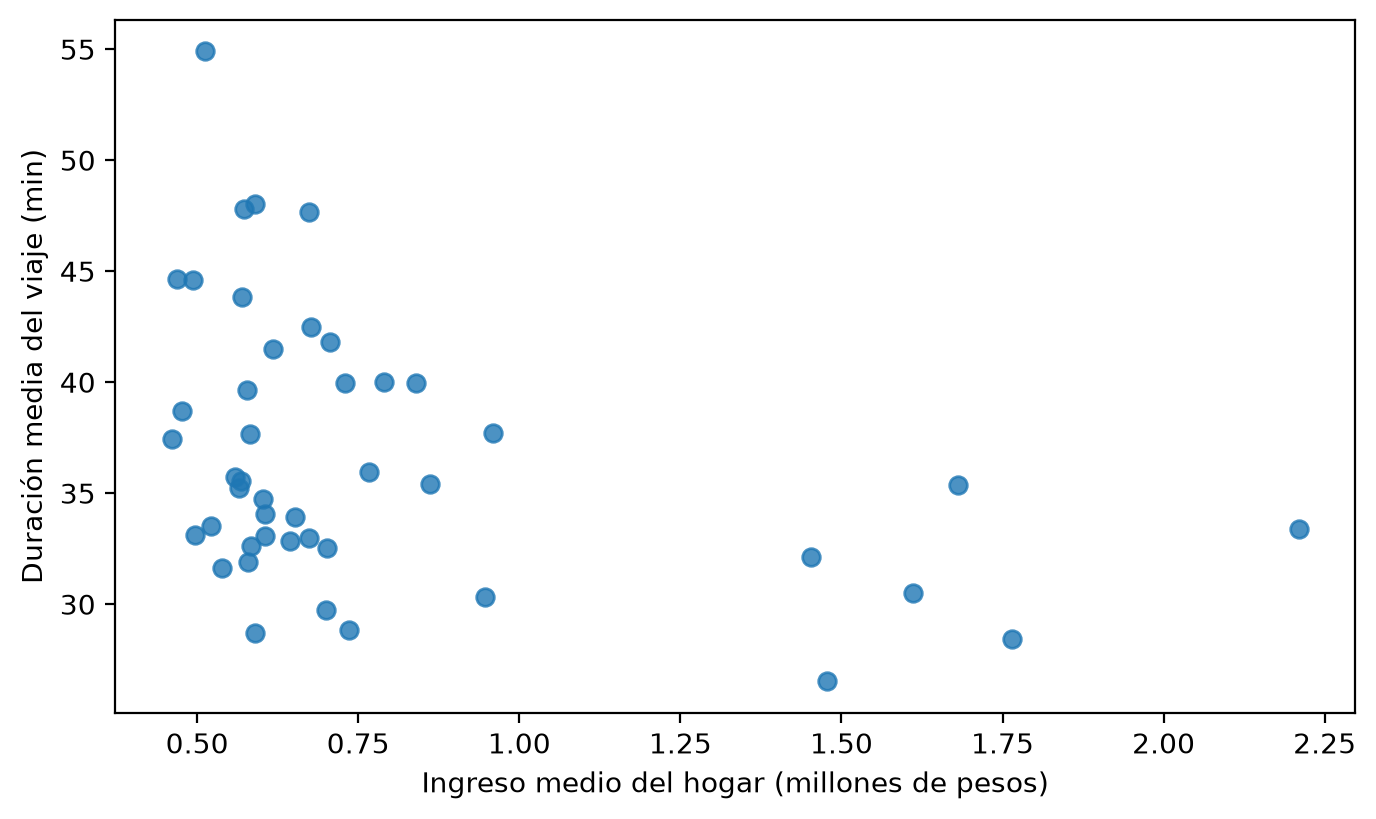

In [14]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(por_comuna["ingreso"] / 1e6, por_comuna["duracion"],
           s=40, alpha=0.8)
ax.set_xlabel("Ingreso medio del hogar (millones de pesos)")
ax.set_ylabel("Duración media del viaje (min)")
plt.show()

La tendencia baja: a mayor ingreso, viajes más cortos. ¿Cuánto? Los dos coeficientes:

In [15]:
x = por_comuna["ingreso"]
y = por_comuna["duracion"]

print("Pearson: ", round(x.corr(y), 2))
print("Spearman:", round(x.corr(y, method="spearman"), 2))

Pearson:  -0.37
Spearman: -0.35


−0,37 y −0,35: una asociación negativa moderada, parecida en ambos coeficientes. La relación existe y se reporta con su tamaño; no toda correlación interesante es 0,9.

### La matriz, con más variables

La tabla por comuna trae otras dos variables: vehículos y personas por hogar. Con cuatro variables hay seis pares; la matriz los muestra todos, y el heatmap la hace legible:

In [16]:
matriz = por_comuna[["ingreso", "duracion", "vehiculos", "personas"]].corr()
matriz.round(2)

,ingreso,duracion,vehiculos,personas
ingreso,1.00,-0.37,0.93,-0.39
duracion,-0.37,1.00,-0.27,0.66
vehiculos,0.93,-0.27,1.00,-0.35
personas,-0.39,0.66,-0.35,1.00


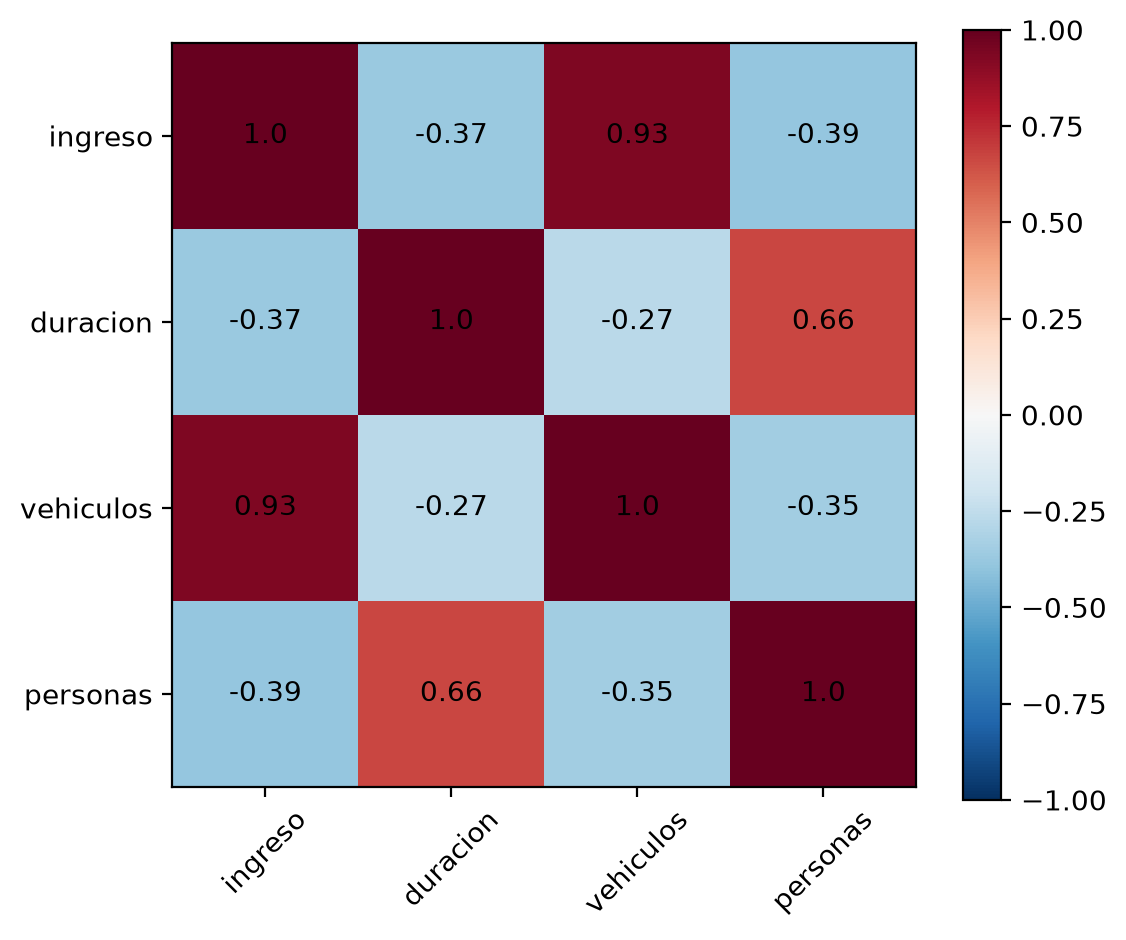

In [17]:
fig, ax = plt.subplots(figsize=(6, 5))
# El heatmap: cada celda coloreada según su correlación
im = ax.imshow(matriz, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(4), matriz.columns, rotation=45)
ax.set_yticks(range(4), matriz.columns)
# Escribimos cada valor sobre su celda
for i in range(4):
    for j in range(4):
        ax.text(j, i, round(matriz.iloc[i, j], 2),
                ha="center", va="center")
fig.colorbar(im)
plt.show()

Cómo se lee, par a par:

- **Ingreso y vehículos: 0,93.** La correlación más fuerte de la tabla: el ingreso compra autos.
- **Personas y duración: 0,66.** La sorpresa: el mejor acompañante de la duración no es el ingreso sino el tamaño del hogar. Las comunas de hogares grandes promedian viajes más largos.
- **Ingreso y duración: −0,37.** La asociación de equidad que ya vimos, moderada.
- **Ingreso y personas: −0,39.** Los hogares de las comunas de mayor ingreso son más chicos.

La matriz no solo describe: sugiere qué variables mirar después (personas por hogar acaba de ganarse un análisis propio) y cuáles son redundantes.

### Los rangos, a mano

Para ver de dónde sale Spearman, `rank()` asigna a cada valor su posición al ordenar; con cinco comunas se puede seguir el cálculo completo:

In [18]:
cinco = por_comuna[por_comuna["Comuna"].isin(
    ["VITACURA", "PROVIDENCIA", "SANTIAGO", "PUENTE ALTO", "CERRO NAVIA"])].copy()

# rank() asigna a cada valor su posición al ordenar
cinco["rango_ingreso"] = cinco["ingreso"].rank()
cinco["rango_duracion"] = cinco["duracion"].rank()
cinco[["Comuna", "ingreso", "duracion", "rango_ingreso", "rango_duracion"]]

,Comuna,ingreso,duracion,rango_ingreso,rango_duracion
3,CERRO NAVIA,4.603270e+05,37.448355,1.0,4.0
30,PROVIDENCIA,1.477094e+06,26.521030,4.0,1.0
32,PUENTE ALTO,6.762274e+05,42.475145,2.0,5.0
41,SANTIAGO,7.353465e+05,28.816162,3.0,3.0
43,VITACURA,1.765041e+06,28.411026,5.0,2.0


Los rangos altos de ingreso van con rangos bajos de duración: eso es una asociación negativa, contada solo con posiciones.

Y la advertencia que acompaña a toda correlación: **correlación no es causalidad**. Que dos variables se muevan juntas no dice que una cause a la otra; con datos observacionales reportamos asociación.

## 4. Grupos y tablas de contingencia

Para dos **categóricas**, el resumen es la tabla de contingencia: cuenta las combinaciones. Veamos el modo de transporte según el sexo. El sexo está en la tabla de personas, así que primero los merges (el modo, igual que la clase pasada; el sexo, con la llave compuesta Hogar y Persona):

In [19]:
modo_por_viaje = pd.read_csv(BASE + "ViajesDifusion.csv", sep=";")
nombres_modo = pd.read_csv(BASE + "tablas_parametros/ModoDifusion.csv", sep=";")
nombres_modo = nombres_modo.rename(columns={"ModoDifusion": "NombreModo"})

viajes_modo = (viajes
    .merge(modo_por_viaje, on="Viaje")
    .merge(nombres_modo, left_on="ModoDifusion", right_on="ID")
    # La llave compuesta: la persona 1 del hogar 2 no es la del hogar 3
    .merge(personas[["Hogar", "Persona", "Sexo"]], on=["Hogar", "Persona"]))

viajes_modo["ModoAgrupado"] = viajes_modo["NombreModo"].where(
    ~viajes_modo["NombreModo"].str.startswith("Bip!"),
    "Bip! (solo o combinado)")
len(viajes_modo)

113591

In [20]:
# El sexo viene como código; el diccionario lo traduce
viajes_modo["SexoNombre"] = viajes_modo["Sexo"].map({1: "Hombre", 2: "Mujer"})

pd.crosstab(viajes_modo["SexoNombre"], viajes_modo["ModoAgrupado"])

ModoAgrupado,Auto,Bicicleta,Bip! (solo o combinado),Caminata,Otros,Taxi,Taxi Colectivo
SexoNombre,,,,,,,
Hombre,14964,2888,17073,12711,4445,598,1125
Mujer,11473,982,18704,21116,4040,1064,2408


Los conteos son difíciles de comparar porque hay más viajes de mujeres que de hombres. `normalize="index"` convierte cada fila en proporciones:

In [21]:
(pd.crosstab(viajes_modo["SexoNombre"], viajes_modo["ModoAgrupado"],
             normalize="index") * 100).round(1)

ModoAgrupado,Auto,Bicicleta,Bip! (solo o combinado),Caminata,Otros,Taxi,Taxi Colectivo
SexoNombre,,,,,,,
Hombre,27.8,5.4,31.7,23.6,8.3,1.1,2.1
Mujer,19.2,1.6,31.3,35.3,6.8,1.8,4.0


Y el cuidado de siempre: estas proporciones describen la muestra. Para hablar de la ciudad se pondera, sumando factores de expansión en vez de contar viajes (aquí, el día laboral normal):

In [22]:
lab = viajes_modo.dropna(subset=["FactorLaboralNormal", "SexoNombre"])

# pivot_table con aggfunc="sum": suma los factores de cada celda
tabla = lab.pivot_table(values="FactorLaboralNormal", index="SexoNombre",
                        columns="ModoAgrupado", aggfunc="sum")

# Cada fila dividida por su total, en porcentaje
(tabla.div(tabla.sum(axis=1), axis=0) * 100).round(1)

ModoAgrupado,Auto,Bicicleta,Bip! (solo o combinado),Caminata,Otros,Taxi,Taxi Colectivo
SexoNombre,,,,,,,
Hombre,28.4,6.0,27.9,26.6,7.7,1.2,2.1
Mujer,19.1,1.9,26.2,40.3,6.2,1.9,4.5


Ponderado, el contraste se acentúa: las mujeres caminan más (40% contra 27%) y los hombres usan más el auto (28% contra 19%) y la bicicleta (6% contra 1,9%). Un hallazgo real de género y movilidad, sacado con dos tablas y un merge.

## 5. La primera regresión

La correlación dijo cuánto se asocian el ingreso y la duración (−0,37); la **regresión lineal** dibuja la recta que mejor resume esa asociación (la de mínimos cuadrados: la que deja la menor suma de errores al cuadrado). Esa recta es un **modelo**: una función que resume los datos y permite predecir. Es el primero del diplomado, y todo lo que viene (más variables, regularización, clasificación) son versiones más ricas de esta misma idea. `np.polyfit` la ajusta; el 1 pide grado 1, una recta:

In [23]:
pendiente, intercepto = np.polyfit(por_comuna["ingreso"] / 1e6,
                                   por_comuna["duracion"], 1)

print("Pendiente: ", round(pendiente, 1), "minutos por millón")
print("Intercepto:", round(intercepto, 1), "minutos")

Pendiente:  -5.8 minutos por millón
Intercepto: 41.1 minutos


Los dos números se interpretan: por cada millón adicional de ingreso medio, la duración media baja casi **6 minutos**; y el intercepto (41 minutos) es donde la recta corta el eje. Ahora la recta sobre los puntos:

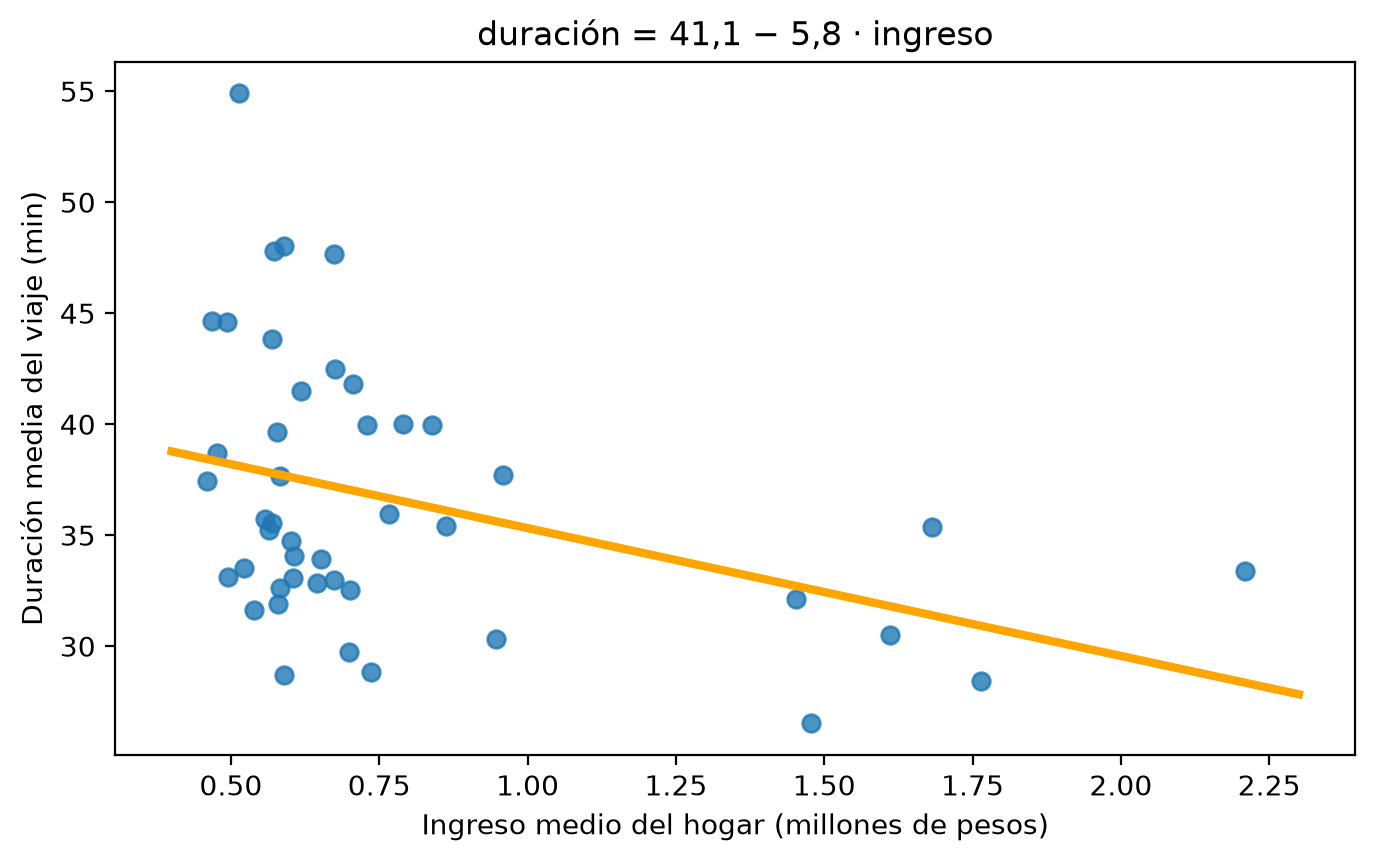

In [24]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(por_comuna["ingreso"] / 1e6, por_comuna["duracion"],
           s=40, alpha=0.8)

# La recta, evaluada en dos puntos del eje x
x = np.array([0.4, 2.3])
ax.plot(x, intercepto + pendiente * x, color="orange", lw=3)
ax.set_xlabel("Ingreso medio del hogar (millones de pesos)")
ax.set_ylabel("Duración media del viaje (min)")
ax.set_title("duración = 41,1 − 5,8 · ingreso")
plt.show()

### Usar la recta

La recta no es solo un dibujo: es una función. Sirve para **predecir** (¿qué duración esperamos en una comuna de ingreso medio 1 millón?) y para medir **residuos**: cuánto se aleja cada comuna de lo que su ingreso predice.

In [25]:
# Predicción para una comuna de ingreso medio 1 millón
print(round(intercepto + pendiente * 1.0, 1), "minutos")

35.3 minutos


In [26]:
# El residuo: lo observado menos lo predicho
por_comuna["prediccion"] = intercepto + pendiente * por_comuna["ingreso"] / 1e6
por_comuna["residuo"] = por_comuna["duracion"] - por_comuna["prediccion"]

# Las comunas que viajan MÁS de lo que su ingreso predice
por_comuna.nlargest(5, "residuo")[["Comuna", "duracion", "prediccion", "residuo"]].round(1)

,Comuna,duracion,prediccion,residuo
15,LA PINTANA,54.9,38.1,16.8
33,QUILICURA,47.7,37.2,10.5
27,PEÑAFLOR,48.0,37.7,10.3
25,PADRE HURTADO,47.8,37.8,10.0
7,EL MONTE,44.6,38.2,6.4


In [27]:
# Y las que viajan MENOS de lo que su ingreso predice
por_comuna.nsmallest(5, "residuo")[["Comuna", "duracion", "prediccion", "residuo"]].round(1)

,Comuna,duracion,prediccion,residuo
0,BUIN,28.7,37.7,-9.0
41,SANTIAGO,28.8,36.8,-8.0
5,CONCHALI,29.7,37.0,-7.3
37,SAN BERNARDO,31.6,38.0,-6.3
30,PROVIDENCIA,26.5,32.6,-6.0


### El impacto de sacar una fila

La clase pasada medimos el impacto de sacar filas comparando un resumen con y sin (la desviación se movía; el IQR no). Con dos variables el mismo experimento se amplifica: una fila mueve varios resúmenes a la vez, y no a todos por igual. La comuna de ingreso más extremo es Lo Barnechea; la sacamos y comparamos todo:

In [28]:
sin_lb = por_comuna[por_comuna["Comuna"] != "LO BARNECHEA"]

print("Con Lo Barnechea: r =", round(por_comuna["ingreso"].corr(por_comuna["duracion"]), 2))
print("Sin Lo Barnechea: r =", round(sin_lb["ingreso"].corr(sin_lb["duracion"]), 2))

Con Lo Barnechea: r = -0.37
Sin Lo Barnechea: r = -0.39


In [29]:
pend2, inter2 = np.polyfit(sin_lb["ingreso"] / 1e6, sin_lb["duracion"], 1)

print("Pendiente  con:", round(pendiente, 1), "| sin:", round(pend2, 1))
print("Intercepto con:", round(intercepto, 1), "| sin:", round(inter2, 1))

Pendiente  con: -5.8 | sin: -7.3
Intercepto con: 41.1 | sin: 42.1


Una sola comuna de 45 casi no mueve la correlación (−0,37 a −0,39), pero cambia la pendiente en un cuarto (−5,8 a −7,3): cada resumen tiene su propia sensibilidad. Por eso el impacto de sacar una fila se mide siempre con y sin, y sobre **todos** los resúmenes que el análisis usa. Los puntos extremos en x, como Lo Barnechea, tienen nombre propio en regresión (puntos de apalancamiento) y los verán formalmente en la clase 6.

La Pintana viaja 17 minutos más de lo que su ingreso predice; Santiago, 8 menos. El residuo separa el efecto del ingreso del resto: lo que queda arriba huele a periferia (distancia al empleo), lo que queda abajo, a centralidad. Los residuos son una herramienta de hallazgos, no solo un error.

Una pregunta queda deliberadamente abierta: ¿es esta pendiente "real" o podría ser azar de estos 45 puntos? Responderla exige las herramientas de la clase 5: hipótesis, valor p y significancia. Por ahora, sepan que la pregunta existe y que tiene respuesta formal.

Esto es un primer contacto: en las clases 6 y 7 la regresión se profundiza (varias variables, diagnósticos y regularización).

## 6. Visualización: muchos puntos y escalas

Dos problemas prácticos de graficar datos reales. El primero: **overplotting**. Para verlo necesitamos muchos puntos, así que calculamos la distancia en línea recta de cada viaje con las coordenadas de origen y destino (en metros). Antes, calidad: hay coordenadas en 0 y fuera de la Región Metropolitana; los rangos válidos del checklist de la clase 2.

In [30]:
coords = ["OrigenCoordX", "OrigenCoordY", "DestinoCoordX", "DestinoCoordY"]
ok = viajes.dropna(subset=coords + ["TiempoViaje"])

# between filtra un rango en una sola condición
for c in ["OrigenCoordX", "DestinoCoordX"]:
    ok = ok[ok[c].between(280_000, 420_000)]
for c in ["OrigenCoordY", "DestinoCoordY"]:
    ok = ok[ok[c].between(6_150_000, 6_450_000)]

len(ok)

89451

In [31]:
dx = ok["DestinoCoordX"] - ok["OrigenCoordX"]
dy = ok["DestinoCoordY"] - ok["OrigenCoordY"]

# Pitágoras, vectorizado, y de metros a kilómetros
ok["DistKm"] = np.sqrt(dx**2 + dy**2) / 1000
ok["DistKm"].describe().round(2)

count    89451.00
mean         6.72
std          7.81
min          0.00
25%          1.43
50%          4.00
75%          9.56
max        137.72
Name: DistKm, dtype: float64

Con 89 mil puntos, el scatter normal se satura: los puntos se tapan y el gráfico miente. El remedio más simple es la transparencia (`alpha`):

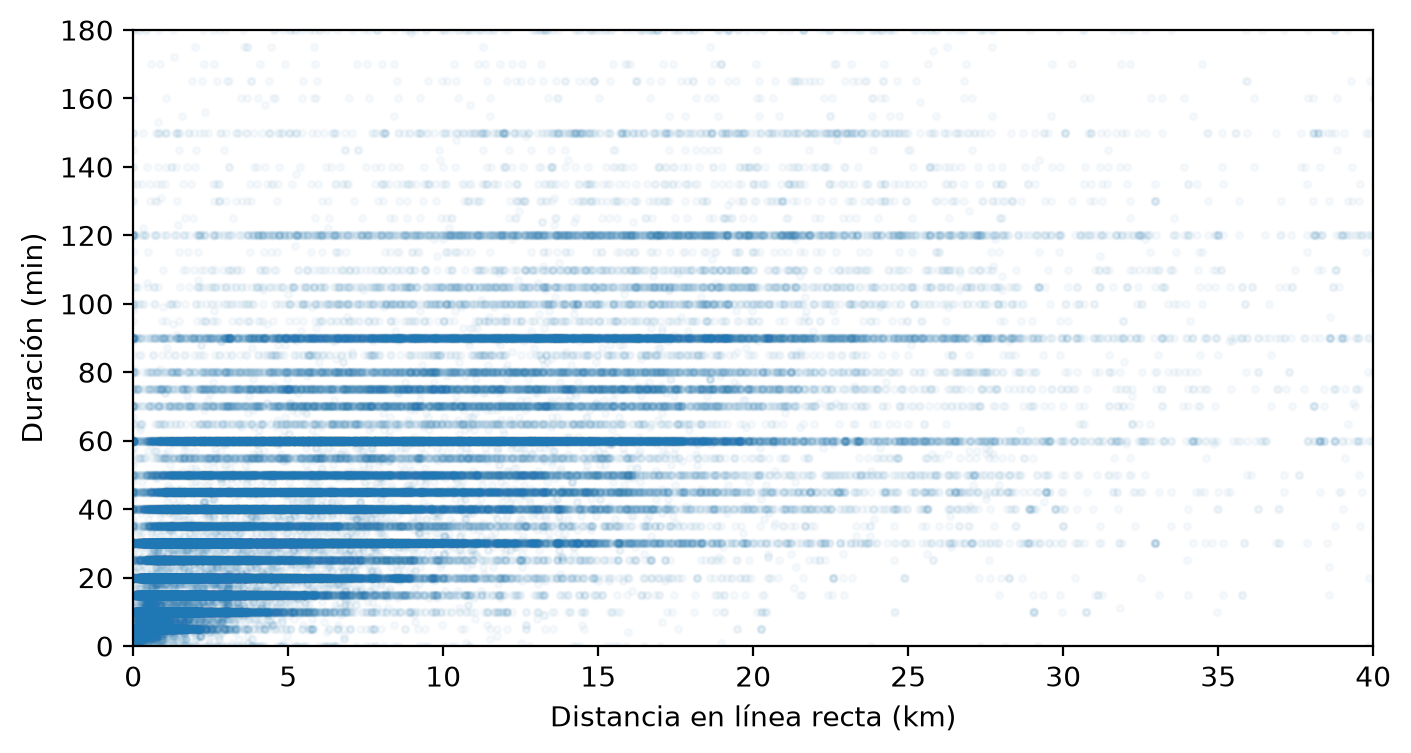

In [32]:
fig, ax = plt.subplots(figsize=(8, 4))
# alpha muy bajo: el color se acumula donde hay muchos puntos
ax.scatter(ok["DistKm"], ok["TiempoViaje"], s=6, alpha=0.03)
ax.set_xlim(0, 40)
ax.set_ylim(0, 180)
ax.set_xlabel("Distancia en línea recta (km)")
ax.set_ylabel("Duración (min)")
plt.show()

Las franjas horizontales son los tiempos redondeados (30, 45, 60): la moda de la clase 2, ahora en dos dimensiones. La alternativa es `hexbin`, donde el color cuenta los viajes por celda:

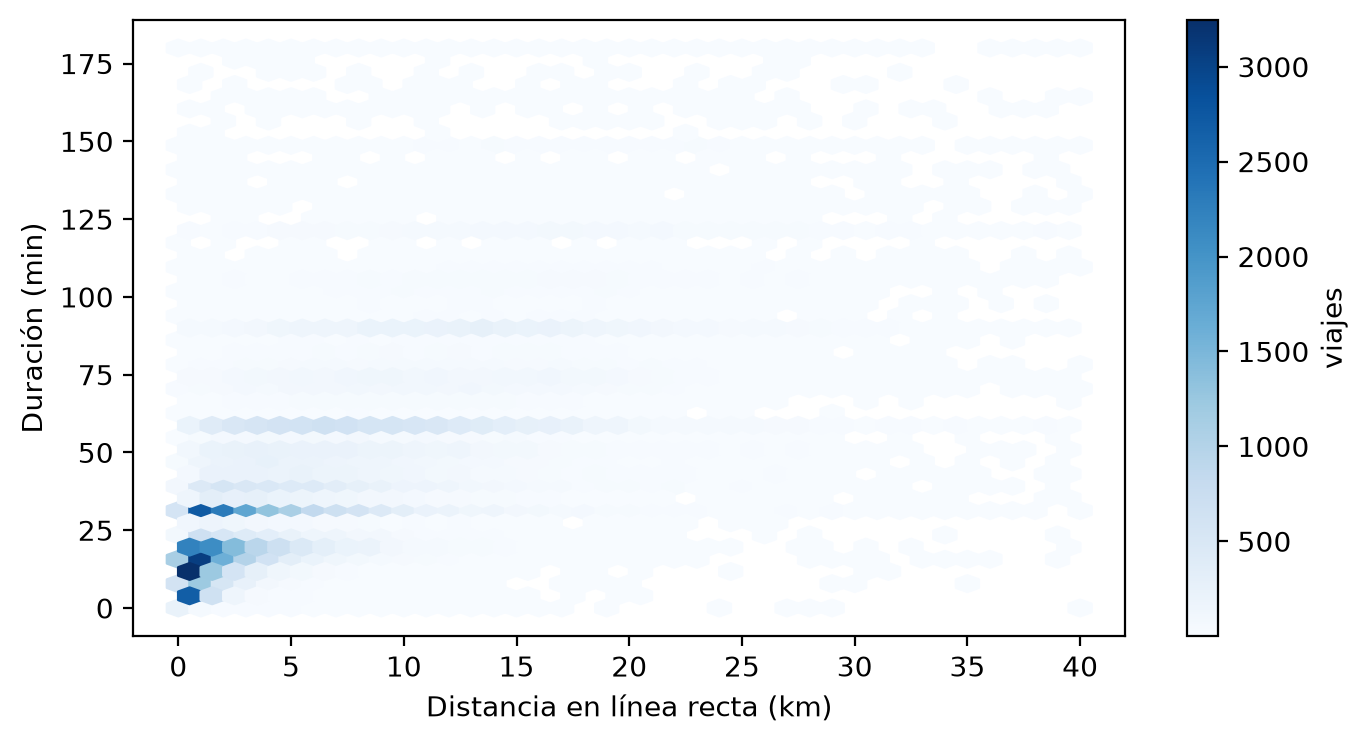

In [33]:
fig, ax = plt.subplots(figsize=(8, 4))
hb = ax.hexbin(ok["DistKm"], ok["TiempoViaje"], gridsize=40,
               cmap="Blues", mincnt=1, extent=(0, 40, 0, 180))
ax.set_xlabel("Distancia en línea recta (km)")
ax.set_ylabel("Duración (min)")
fig.colorbar(hb, label="viajes")
plt.show()

El segundo problema: **colas largas**. Con variables como el ingreso, la escala lineal aplasta el 99% de los datos contra el borde; graficar el logaritmo reparte el espacio y la forma aparece:

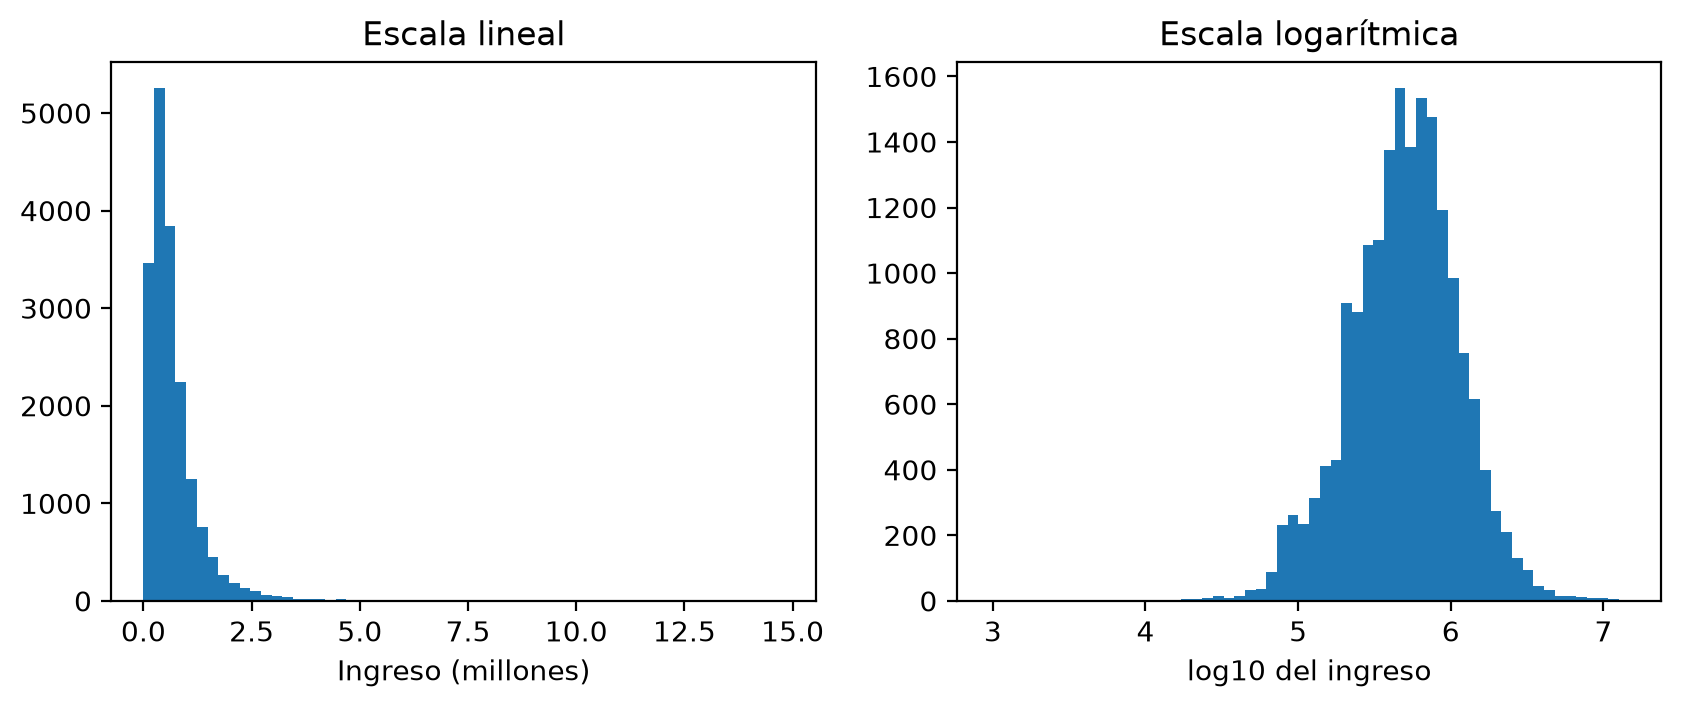

In [34]:
ingreso = hogares["IngresoHogar"].dropna()
# El logaritmo no acepta ceros
ingreso = ingreso[ingreso > 0]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(ingreso / 1e6, bins=60)
axes[0].set_title("Escala lineal")
axes[0].set_xlabel("Ingreso (millones)")
axes[1].hist(np.log10(ingreso), bins=60)
axes[1].set_title("Escala logarítmica")
axes[1].set_xlabel("log10 del ingreso")
plt.show()

En log10, un 6 es un millón de pesos y un 7, diez millones: cada paso del eje multiplica por 10.

## 7. Ejercicio (voluntario)

Con los datos de su proyecto (o con la EOD si aún no los tiene):

1. La matriz de correlación de sus variables cuantitativas. ¿Hay pares redundantes? ¿Cuáles descartaría?
2. Un scatter de las dos variables más relevantes para su pregunta, cuidando el overplotting si hay muchas filas.
3. Una tabla de contingencia o un groupby que cruce una categórica con su variable de interés.

Todo esto es material directo para el primer análisis exploratorio, que se entrega el lunes 15.

In [35]:
# Su solución


---

**Próxima clase (jueves 03-sep):** presentaciones breves de las ideas de proyecto (5 minutos por equipo, sin nota) y fundamentos de probabilidad. Recuerde: la formulación del Capstone se entrega el lunes 7 de septiembre.